# Initial Data Analysis — NASA C-MAPSS Dataset

**Project:** Bayesian Digital Twins for Predictive Maintenance  
**Dataset:** NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS)  
**Goal:** First-pass data quality checks, schema understanding, and structural characterization of all four sub-datasets (FD001–FD004).

---

## Contents

1. Setup & Imports  
2. Data Loading  
3. Dataset Dimensions & Schema  
4. Data Types & Missing Values  
5. Unit / Engine ID Structure  
6. Cycle Length Distributions  
7. Operating Conditions  
8. Sensor Variable Identification  
9. Descriptive Statistics  
10. RUL Label Structure  
11. Summary & Key Findings

---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
FIG_DIR     = Path('../output/figures/IDA')
TABLE_DIR   = Path('../output/tables/IDA')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

print('Setup complete.')

Setup complete.


---
## 2. Data Loading

C-MAPSS files are whitespace-delimited with no header row.  
Each row represents one engine cycle. The 26 columns are:

| Position | Name | Description |
|---|---|---|
| 0 | `unit_id` | Engine (unit) number |
| 1 | `cycle` | Operational cycle counter |
| 2–4 | `setting_1/2/3` | Operational setting variables |
| 5–25 | `s1`–`s21` | Sensor measurements (T2 through W32) |

In [2]:
# ── Column schema ──────────────────────────────────────────────────────────────
INDEX_COLS   = ['unit_id', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']

# Sensor names in order (from readme.txt / Damage Propagation Modeling.pdf)
SENSOR_NAMES = [
    'T2',    # Total temperature at fan inlet (°R)
    'T24',   # Total temperature at LPC outlet (°R)
    'T30',   # Total temperature at HPC outlet (°R)
    'T50',   # Total temperature at LPT outlet (°R)
    'P2',    # Pressure at fan inlet (psia)
    'P15',   # Total pressure in bypass-duct (psia)
    'P30',   # Total pressure at HPC outlet (psia)
    'Nf',    # Physical fan speed (rpm)
    'Nc',    # Physical core speed (rpm)
    'epr',   # Engine pressure ratio (P50/P2)
    'Ps30',  # Static pressure at HPC outlet (psia)
    'phi',   # Ratio of fuel flow to Ps30
    'NRf',   # Corrected fan speed (rpm)
    'NRc',   # Corrected core speed (rpm)
    'BPR',   # Bypass ratio
    'farB',  # Burner fuel-air ratio
    'htBleed', # Bleed enthalpy
    'Nf_dmd',  # Demanded fan speed (rpm)
    'PCNfR_dmd', # Demanded corrected fan speed (rpm)
    'W31',   # HPT coolant bleed (lbm/s)
    'W32',   # LPT coolant bleed (lbm/s)
]

ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_NAMES

print(f'Total columns: {len(ALL_COLS)}')
print(f'Sensor columns: {len(SENSOR_NAMES)}')

Total columns: 26
Sensor columns: 21


In [3]:
def load_dataset(name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """Load train, test, and RUL files for one C-MAPSS sub-dataset."""
    train = pd.read_csv(
        DATA_DIR / f'train_{name}.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    test = pd.read_csv(
        DATA_DIR / f'test_{name}.txt',
        sep=r'\s+', header=None, names=ALL_COLS
    )
    rul = pd.read_csv(
        DATA_DIR / f'RUL_{name}.txt',
        sep=r'\s+', header=None, names=['true_rul']
    )['true_rul']
    return train, test, rul


def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    """Compute and append RUL column for a training set."""
    df = df.copy()
    max_cycle = df.groupby('unit_id')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df


# Load all four sub-datasets
data = {}
for ds in DATASETS:
    train, test, rul = load_dataset(ds)
    data[ds] = {
        'train': add_rul(train),
        'test':  test,
        'rul':   rul,
    }
    print(f'{ds}: train={train.shape}, test={test.shape}, rul_labels={len(rul)}')

FD001: train=(20631, 26), test=(13096, 26), rul_labels=100


FD002: train=(53759, 26), test=(33991, 26), rul_labels=259


FD003: train=(24720, 26), test=(16596, 26), rul_labels=100


FD004: train=(61249, 26), test=(41214, 26), rul_labels=248


---
## 3. Dataset Dimensions & Schema

C-MAPSS contains four sub-datasets with different numbers of operating conditions and fault modes:

| Dataset | Operating Conditions | Fault Mode |
|---|---|---|
| FD001 | 1 | HPC degradation |
| FD002 | 6 | HPC degradation |
| FD003 | 1 | HPC + fan degradation |
| FD004 | 6 | HPC + fan degradation |

In [4]:
rows = []
for ds in DATASETS:
    tr = data[ds]['train']
    te = data[ds]['test']
    ru = data[ds]['rul']
    rows.append({
        'Dataset':         ds,
        'Train rows':      tr.shape[0],
        'Test rows':       te.shape[0],
        'Columns':         len(ALL_COLS),
        'Train engines':   tr['unit_id'].nunique(),
        'Test engines':    te['unit_id'].nunique(),
        'RUL labels':      len(ru),
    })

dim_df = pd.DataFrame(rows).set_index('Dataset')
display(dim_df)
dim_df.to_csv(TABLE_DIR / 'dataset_dimensions.csv')
print('Saved → output/tables/IDA/dataset_dimensions.csv')

,Train rows,Test rows,Columns,Train engines,Test engines,RUL labels
Dataset,,,,,,
FD001,20631,13096,26,100,100,100
FD002,53759,33991,26,260,259,259
FD003,24720,16596,26,100,100,100
FD004,61249,41214,26,249,248,248


Saved → output/tables/IDA/dataset_dimensions.csv


In [5]:
# Inspect column schema on FD001 training set
print('Column names:')
print(data['FD001']['train'].columns.tolist())
print()
data['FD001']['train'].head(3)

Column names:
['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL']



,unit_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189


---
## 4. Data Types & Missing Values

In [6]:
print('=== Data Types (FD001 train) ===')
print(data['FD001']['train'].dtypes.to_string())

=== Data Types (FD001 train) ===
unit_id        int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
T2           float64
T24          float64
T30          float64
T50          float64
P2           float64
P15          float64
P30          float64
Nf           float64
Nc           float64
epr          float64
Ps30         float64
phi          float64
NRf          float64
NRc          float64
BPR          float64
farB         float64
htBleed        int64
Nf_dmd         int64
PCNfR_dmd    float64
W31          float64
W32          float64
RUL            int64


In [7]:
# Missing values across all splits and datasets
mv_rows = []
for ds in DATASETS:
    for split in ['train', 'test']:
        df = data[ds][split]
        n_missing = df.isnull().sum().sum()
        mv_rows.append({'Dataset': ds, 'Split': split,
                        'Total cells': df.size,
                        'Missing cells': n_missing,
                        'Missing %': f'{100*n_missing/df.size:.4f}%'})

mv_df = pd.DataFrame(mv_rows)
display(mv_df)
mv_df.to_csv(TABLE_DIR / 'missing_values.csv', index=False)
print('Saved → output/tables/IDA/missing_values.csv')

,Dataset,Split,Total cells,Missing cells,Missing %
0,FD001,train,557037,0,0.0000%
1,FD001,test,340496,0,0.0000%
2,FD002,train,1451493,0,0.0000%
3,FD002,test,883766,0,0.0000%
4,FD003,train,667440,0,0.0000%
5,FD003,test,431496,0,0.0000%
6,FD004,train,1653723,0,0.0000%
7,FD004,test,1071564,0,0.0000%


Saved → output/tables/IDA/missing_values.csv


In [8]:
# Duplicate rows
dup_rows = []
for ds in DATASETS:
    for split in ['train', 'test']:
        df = data[ds][split]
        n_dup = df.duplicated().sum()
        dup_rows.append({'Dataset': ds, 'Split': split, 'Duplicate rows': n_dup})

display(pd.DataFrame(dup_rows))

,Dataset,Split,Duplicate rows
0,FD001,train,0
1,FD001,test,0
2,FD002,train,0
3,FD002,test,0
4,FD003,train,0
5,FD003,test,0
6,FD004,train,0
7,FD004,test,0


---
## 5. Unit / Engine ID Structure

In [9]:
engine_rows = []
for ds in DATASETS:
    for split in ['train', 'test']:
        df = data[ds][split]
        ids = df['unit_id'].unique()
        engine_rows.append({
            'Dataset': ds, 'Split': split,
            'Engine IDs (min–max)': f"{ids.min()}–{ids.max()}",
            'Count': len(ids),
            'Contiguous': ids.max() - ids.min() + 1 == len(ids),
        })

eng_df = pd.DataFrame(engine_rows)
display(eng_df)
eng_df.to_csv(TABLE_DIR / 'engine_ids.csv', index=False)
print('Saved → output/tables/IDA/engine_ids.csv')

,Dataset,Split,Engine IDs (min–max),Count,Contiguous
0,FD001,train,1–100,100,True
1,FD001,test,1–100,100,True
2,FD002,train,1–260,260,True
3,FD002,test,1–259,259,True
4,FD003,train,1–100,100,True
5,FD003,test,1–100,100,True
6,FD004,train,1–249,249,True
7,FD004,test,1–248,248,True


Saved → output/tables/IDA/engine_ids.csv


---
## 6. Cycle Length Distributions

Cycle length = number of operational cycles observed per engine. In the training set this equals the engine's lifetime (failure time). In the test set it is a truncated sequence — the engine was still running when observation stopped.

In [10]:
cycle_stats_rows = []
for ds in DATASETS:
    for split in ['train', 'test']:
        df = data[ds][split]
        lengths = df.groupby('unit_id')['cycle'].max()
        cycle_stats_rows.append({
            'Dataset': ds, 'Split': split,
            'Min cycles': int(lengths.min()),
            'Median cycles': int(lengths.median()),
            'Mean cycles': f'{lengths.mean():.1f}',
            'Max cycles': int(lengths.max()),
            'Std': f'{lengths.std():.1f}',
        })

cs_df = pd.DataFrame(cycle_stats_rows)
display(cs_df)
cs_df.to_csv(TABLE_DIR / 'cycle_length_stats.csv', index=False)
print('Saved → output/tables/IDA/cycle_length_stats.csv')

,Dataset,Split,Min cycles,Median cycles,Mean cycles,Max cycles,Std
0,FD001,train,128,199,206.3,362,46.3
1,FD001,test,31,133,131.0,303,53.6
2,FD002,train,128,199,206.8,378,46.8
3,FD002,test,21,132,131.2,367,63.1
4,FD003,train,145,220,247.2,525,86.5
5,FD003,test,38,148,166.0,475,86.9
6,FD004,train,128,234,246.0,543,73.1
7,FD004,test,19,153,166.2,486,91.6


Saved → output/tables/IDA/cycle_length_stats.csv


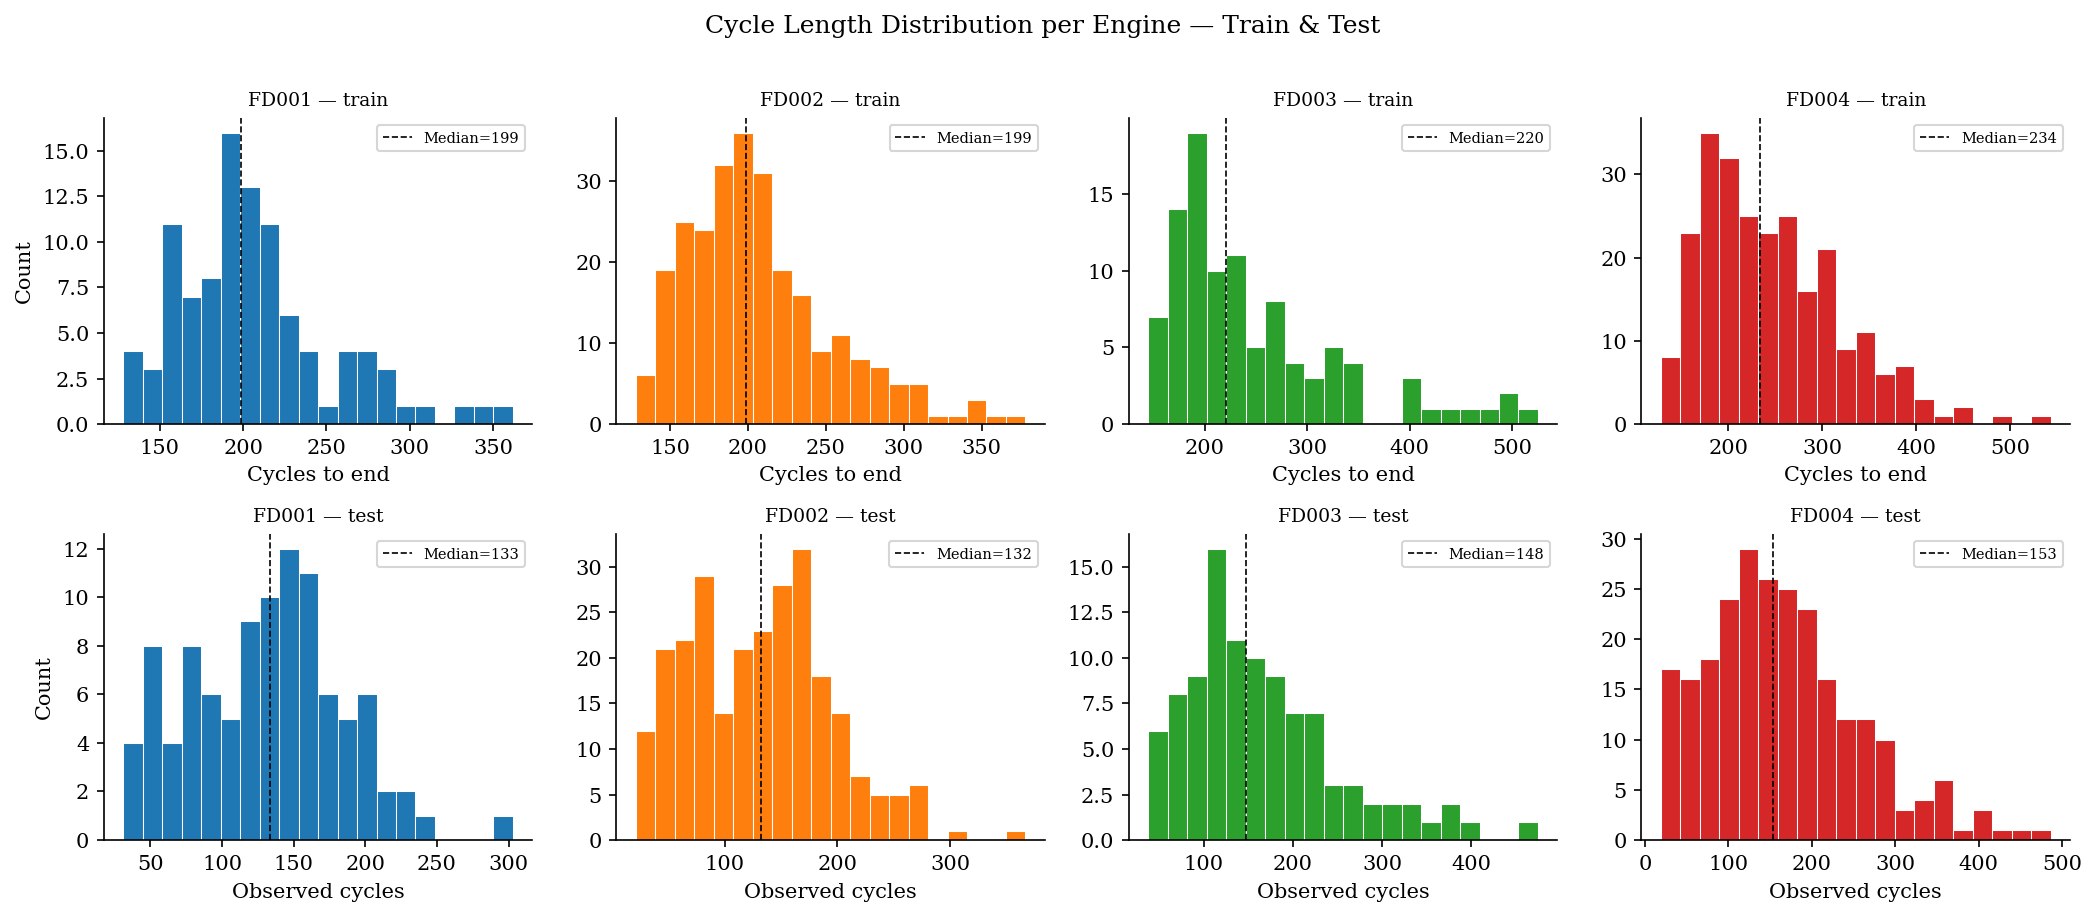

Saved → output/figures/IDA/cycle_length_distributions.png


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
fig.suptitle('Cycle Length Distribution per Engine — Train & Test', fontsize=12, y=1.01)

for col, ds in enumerate(DATASETS):
    for row, split in enumerate(['train', 'test']):
        ax = axes[row, col]
        lengths = data[ds][split].groupby('unit_id')['cycle'].max()
        ax.hist(lengths, bins=20, color=PALETTE[col], edgecolor='white', linewidth=0.5)
        ax.set_title(f'{ds} — {split}', fontsize=9)
        ax.set_xlabel('Cycles to end' if split == 'train' else 'Observed cycles')
        ax.set_ylabel('Count' if col == 0 else '')
        ax.axvline(lengths.median(), color='k', linestyle='--', linewidth=0.8, label=f'Median={int(lengths.median())}')
        ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cycle_length_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/cycle_length_distributions.png')

---
## 7. Operating Conditions

Three operational setting variables (`setting_1`, `setting_2`, `setting_3`) encode the flight regime. FD001/FD003 use a single operating condition; FD002/FD004 use six. This matters for sensor normalization — sensors must be conditioned on the operating point.

In [12]:
oc_rows = []
for ds in DATASETS:
    tr = data[ds]['train']
    for col in SETTING_COLS:
        oc_rows.append({
            'Dataset': ds,
            'Setting': col,
            'Unique values': tr[col].nunique(),
            'Min': tr[col].min(),
            'Max': tr[col].max(),
            'Sample values': str(sorted(tr[col].unique())[:8]),
        })

oc_df = pd.DataFrame(oc_rows)
display(oc_df)
oc_df.to_csv(TABLE_DIR / 'operating_conditions.csv', index=False)
print('Saved → output/tables/IDA/operating_conditions.csv')

,Dataset,Setting,Unique values,Min,Max,Sample values
0,FD001,setting_1,158,-0.0087,0.0087,"[np.float64(-0.0087), np.float64(-0.0086), np...."
1,FD001,setting_2,13,-0.0006,0.0006,"[np.float64(-0.0006), np.float64(-0.0005), np...."
2,FD001,setting_3,1,100.0000,100.0000,[np.float64(100.0)]
3,FD002,setting_1,536,0.0000,42.0080,"[np.float64(0.0), np.float64(0.0001), np.float..."
4,FD002,setting_2,105,0.0000,0.8420,"[np.float64(0.0), np.float64(0.0001), np.float..."
5,FD002,setting_3,2,60.0000,100.0000,"[np.float64(60.0), np.float64(100.0)]"
6,FD003,setting_1,160,-0.0086,0.0086,"[np.float64(-0.0086), np.float64(-0.0085), np...."
7,FD003,setting_2,14,-0.0006,0.0007,"[np.float64(-0.0006), np.float64(-0.0005), np...."
8,FD003,setting_3,1,100.0000,100.0000,[np.float64(100.0)]
9,FD004,setting_1,536,0.0000,42.0080,"[np.float64(0.0), np.float64(0.0001), np.float..."


Saved → output/tables/IDA/operating_conditions.csv


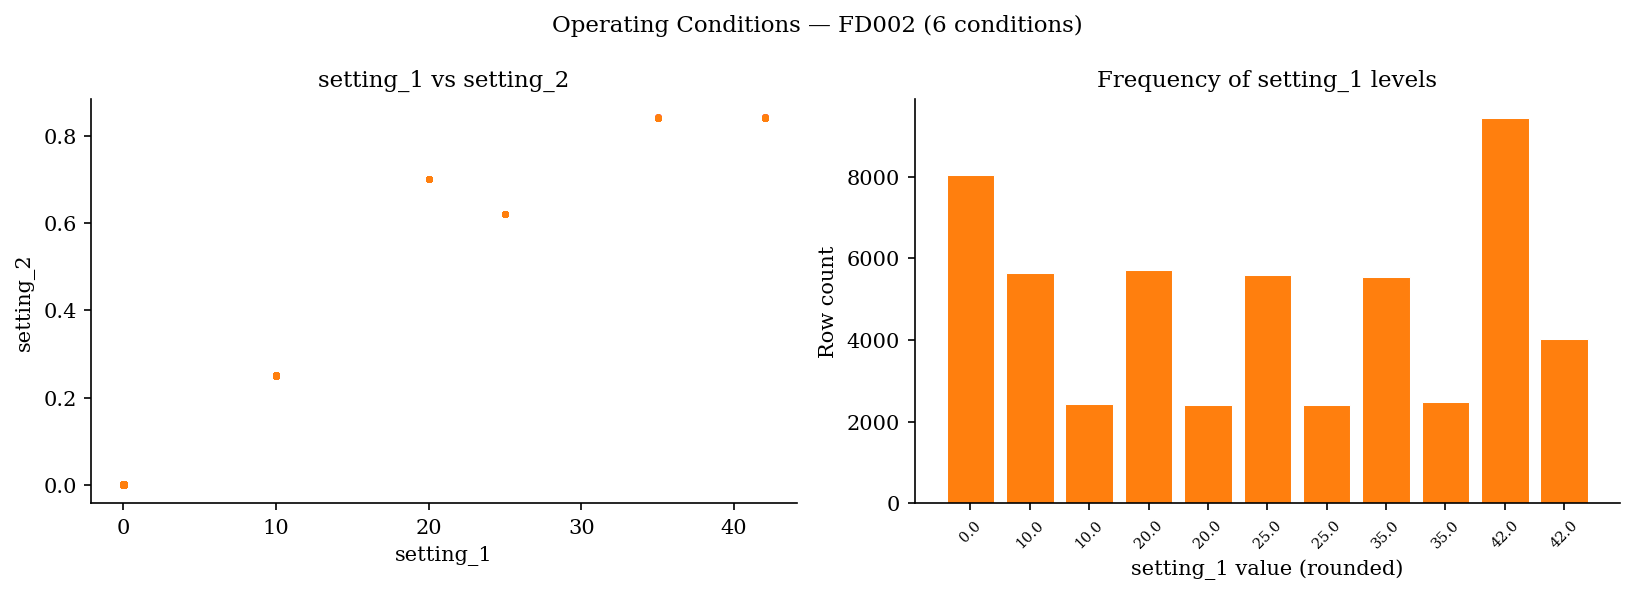

Saved → output/figures/IDA/operating_conditions_FD002.png


In [13]:
# Visualise operating regime clusters for FD002 (6 conditions)
tr_fd002 = data['FD002']['train']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Operating Conditions — FD002 (6 conditions)', fontsize=11)

ax = axes[0]
ax.scatter(tr_fd002['setting_1'], tr_fd002['setting_2'],
           alpha=0.08, s=4, color=PALETTE[1])
ax.set_xlabel('setting_1'); ax.set_ylabel('setting_2')
ax.set_title('setting_1 vs setting_2')

ax = axes[1]
# Round setting_1 to cluster and show distribution
s1_vals = sorted(tr_fd002['setting_1'].round(2).unique())
counts = tr_fd002['setting_1'].round(2).value_counts().sort_index()
ax.bar(range(len(counts)), counts.values, color=PALETTE[1], edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([f'{v:.1f}' for v in counts.index], rotation=45, fontsize=7)
ax.set_xlabel('setting_1 value (rounded)'); ax.set_ylabel('Row count')
ax.set_title('Frequency of setting_1 levels')

plt.tight_layout()
fig.savefig(FIG_DIR / 'operating_conditions_FD002.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/operating_conditions_FD002.png')

In [14]:
# Cluster operating conditions using rounded setting_1 + setting_2 for FD002/FD004
for ds in ['FD002', 'FD004']:
    tr = data[ds]['train'].copy()
    tr['op_cluster'] = tr['setting_1'].round(0).astype(int).astype(str) + '_' + tr['setting_2'].round(2).astype(str)
    n_clusters = tr['op_cluster'].nunique()
    print(f'{ds}: {n_clusters} operating clusters identified')
    print(tr.groupby('op_cluster').size().sort_values(ascending=False).head(8))
    print()

FD002: 6 operating clusters identified
op_cluster
42_0.84    13458
20_0.7      8122
10_0.25     8096
0_0.0       8044
35_0.84     8037
25_0.62     8002
dtype: int64

FD004: 6 operating clusters identified
op_cluster
42_0.84    15395
0_0.0       9238
10_0.25     9224
35_0.84     9162
25_0.62     9139
20_0.7      9091
dtype: int64



---
## 8. Sensor Variable Identification

Not all 21 sensors carry information — some are constant across the entire dataset (zero variance), others are highly collinear. We identify:
- **Constant sensors:** variance = 0 across the full training set
- **Near-constant sensors:** coefficient of variation < 0.01

In [15]:
sensor_info_rows = []
for ds in DATASETS:
    tr = data[ds]['train']
    for s in SENSOR_NAMES:
        vals = tr[s]
        std = vals.std()
        mean = vals.mean()
        cv = std / abs(mean) if mean != 0 else np.nan
        sensor_info_rows.append({
            'Dataset': ds, 'Sensor': s,
            'Mean': round(mean, 4), 'Std': round(std, 6),
            'CV': round(cv, 4) if not np.isnan(cv) else np.nan,
            'Constant': std == 0,
            'Near-constant (CV<0.01)': (not np.isnan(cv)) and (cv < 0.01),
        })

si_df = pd.DataFrame(sensor_info_rows)

# Pivot: which sensors are constant in which dataset?
const_pivot = si_df.pivot_table(index='Sensor', columns='Dataset', values='Constant', aggfunc='first')
print('Constant sensors (True = zero variance):')
display(const_pivot[const_pivot.any(axis=1)])

Constant sensors (True = zero variance):


Dataset,FD001,FD002,FD003,FD004
Sensor,,,,
Nf_dmd,True,False,True,False
PCNfR_dmd,True,False,True,False
T2,True,False,True,False
epr,True,False,False,False


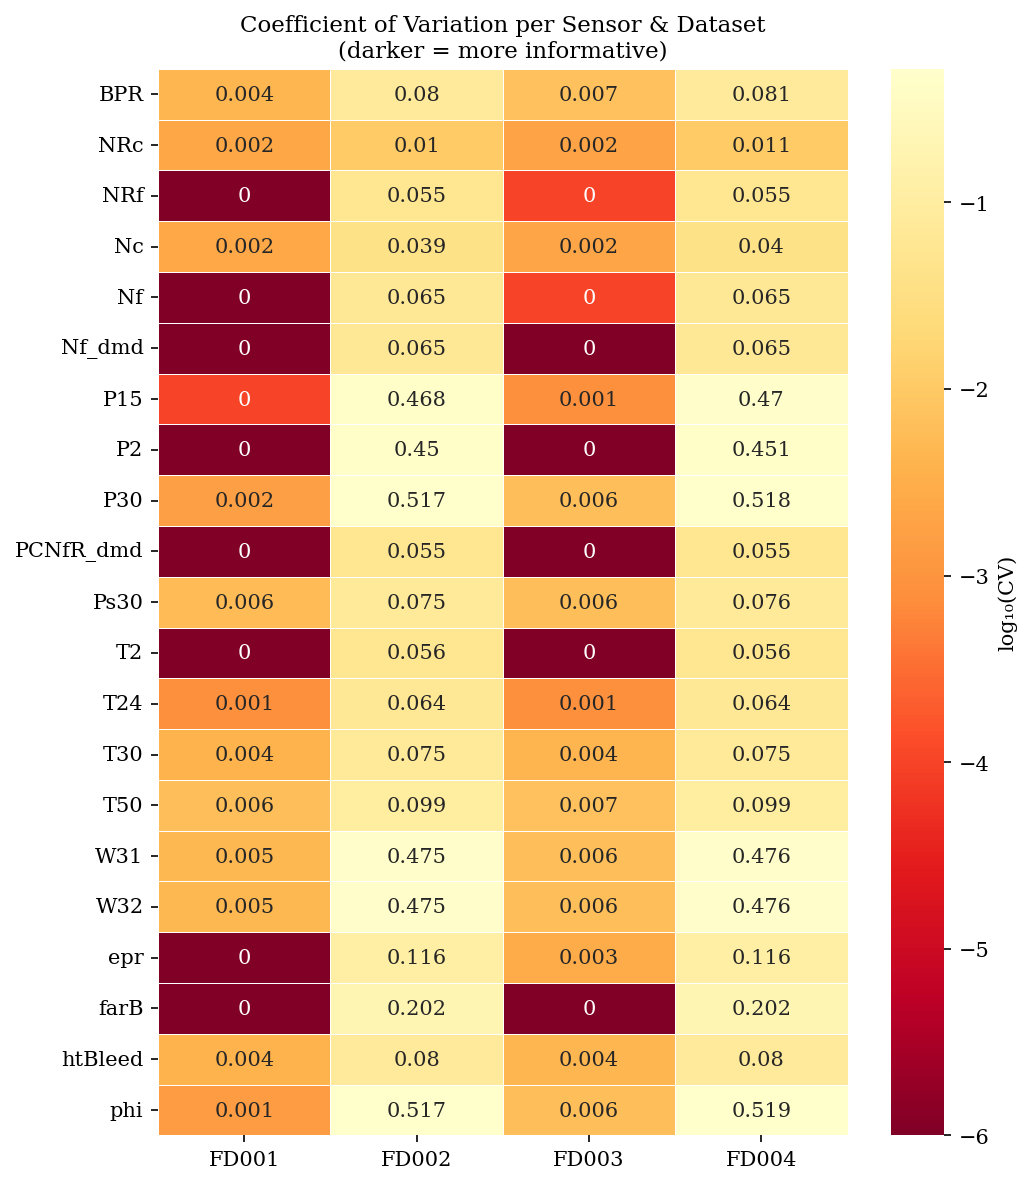

Saved → output/figures/IDA/sensor_cv_heatmap.png


In [16]:
# Sensor variance heatmap (log-CV) — one row per sensor, one column per dataset
cv_pivot = si_df.pivot_table(index='Sensor', columns='Dataset', values='CV', aggfunc='first')
cv_log = np.log10(cv_pivot.clip(lower=1e-6))  # log scale for readability

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    cv_log, annot=cv_pivot.round(3), fmt='g',
    cmap='YlOrRd_r', linewidths=0.4, ax=ax,
    cbar_kws={'label': 'log₁₀(CV)'}
)
ax.set_title('Coefficient of Variation per Sensor & Dataset\n(darker = more informative)', fontsize=11)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_cv_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/sensor_cv_heatmap.png')

In [17]:
# Summary: informative vs constant sensors per dataset
for ds in DATASETS:
    subset = si_df[si_df['Dataset'] == ds]
    n_const = subset['Constant'].sum()
    n_near  = subset['Near-constant (CV<0.01)'].sum() - n_const
    n_info  = len(subset) - n_const - n_near
    const_list = subset.loc[subset['Constant'], 'Sensor'].tolist()
    print(f'{ds}: {n_info} informative | {n_near} near-constant | {n_const} constant → {const_list}')

si_df.to_csv(TABLE_DIR / 'sensor_variability.csv', index=False)
print('\nSaved → output/tables/IDA/sensor_variability.csv')

FD001: 0 informative | 17 near-constant | 4 constant → ['T2', 'epr', 'Nf_dmd', 'PCNfR_dmd']
FD002: 21 informative | 0 near-constant | 0 constant → []
FD003: 0 informative | 18 near-constant | 3 constant → ['T2', 'Nf_dmd', 'PCNfR_dmd']
FD004: 21 informative | 0 near-constant | 0 constant → []

Saved → output/tables/IDA/sensor_variability.csv


---
## 9. Descriptive Statistics

In [18]:
for ds in DATASETS:
    tr = data[ds]['train']
    stats = tr[SENSOR_NAMES].describe().T.round(3)
    stats.to_csv(TABLE_DIR / f'descriptive_stats_{ds}.csv')
    print(f'{ds} descriptive stats saved.')

# Display FD001 as example
print('\nFD001 Sensor Descriptive Statistics:')
display(data['FD001']['train'][SENSOR_NAMES].describe().T.round(3))

FD001 descriptive stats saved.


FD002 descriptive stats saved.
FD003 descriptive stats saved.


FD004 descriptive stats saved.

FD001 Sensor Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
T2,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
T24,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
T30,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
T50,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
P2,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620
P15,20631.0,21.610,0.001,21.600,21.610,21.610,21.610,21.610
P30,20631.0,553.368,0.885,549.850,552.810,553.440,554.010,556.060
Nf,20631.0,2388.097,0.071,2387.900,2388.050,2388.090,2388.140,2388.560
Nc,20631.0,9065.243,22.083,9021.730,9053.100,9060.660,9069.420,9244.590
epr,20631.0,1.300,0.000,1.300,1.300,1.300,1.300,1.300


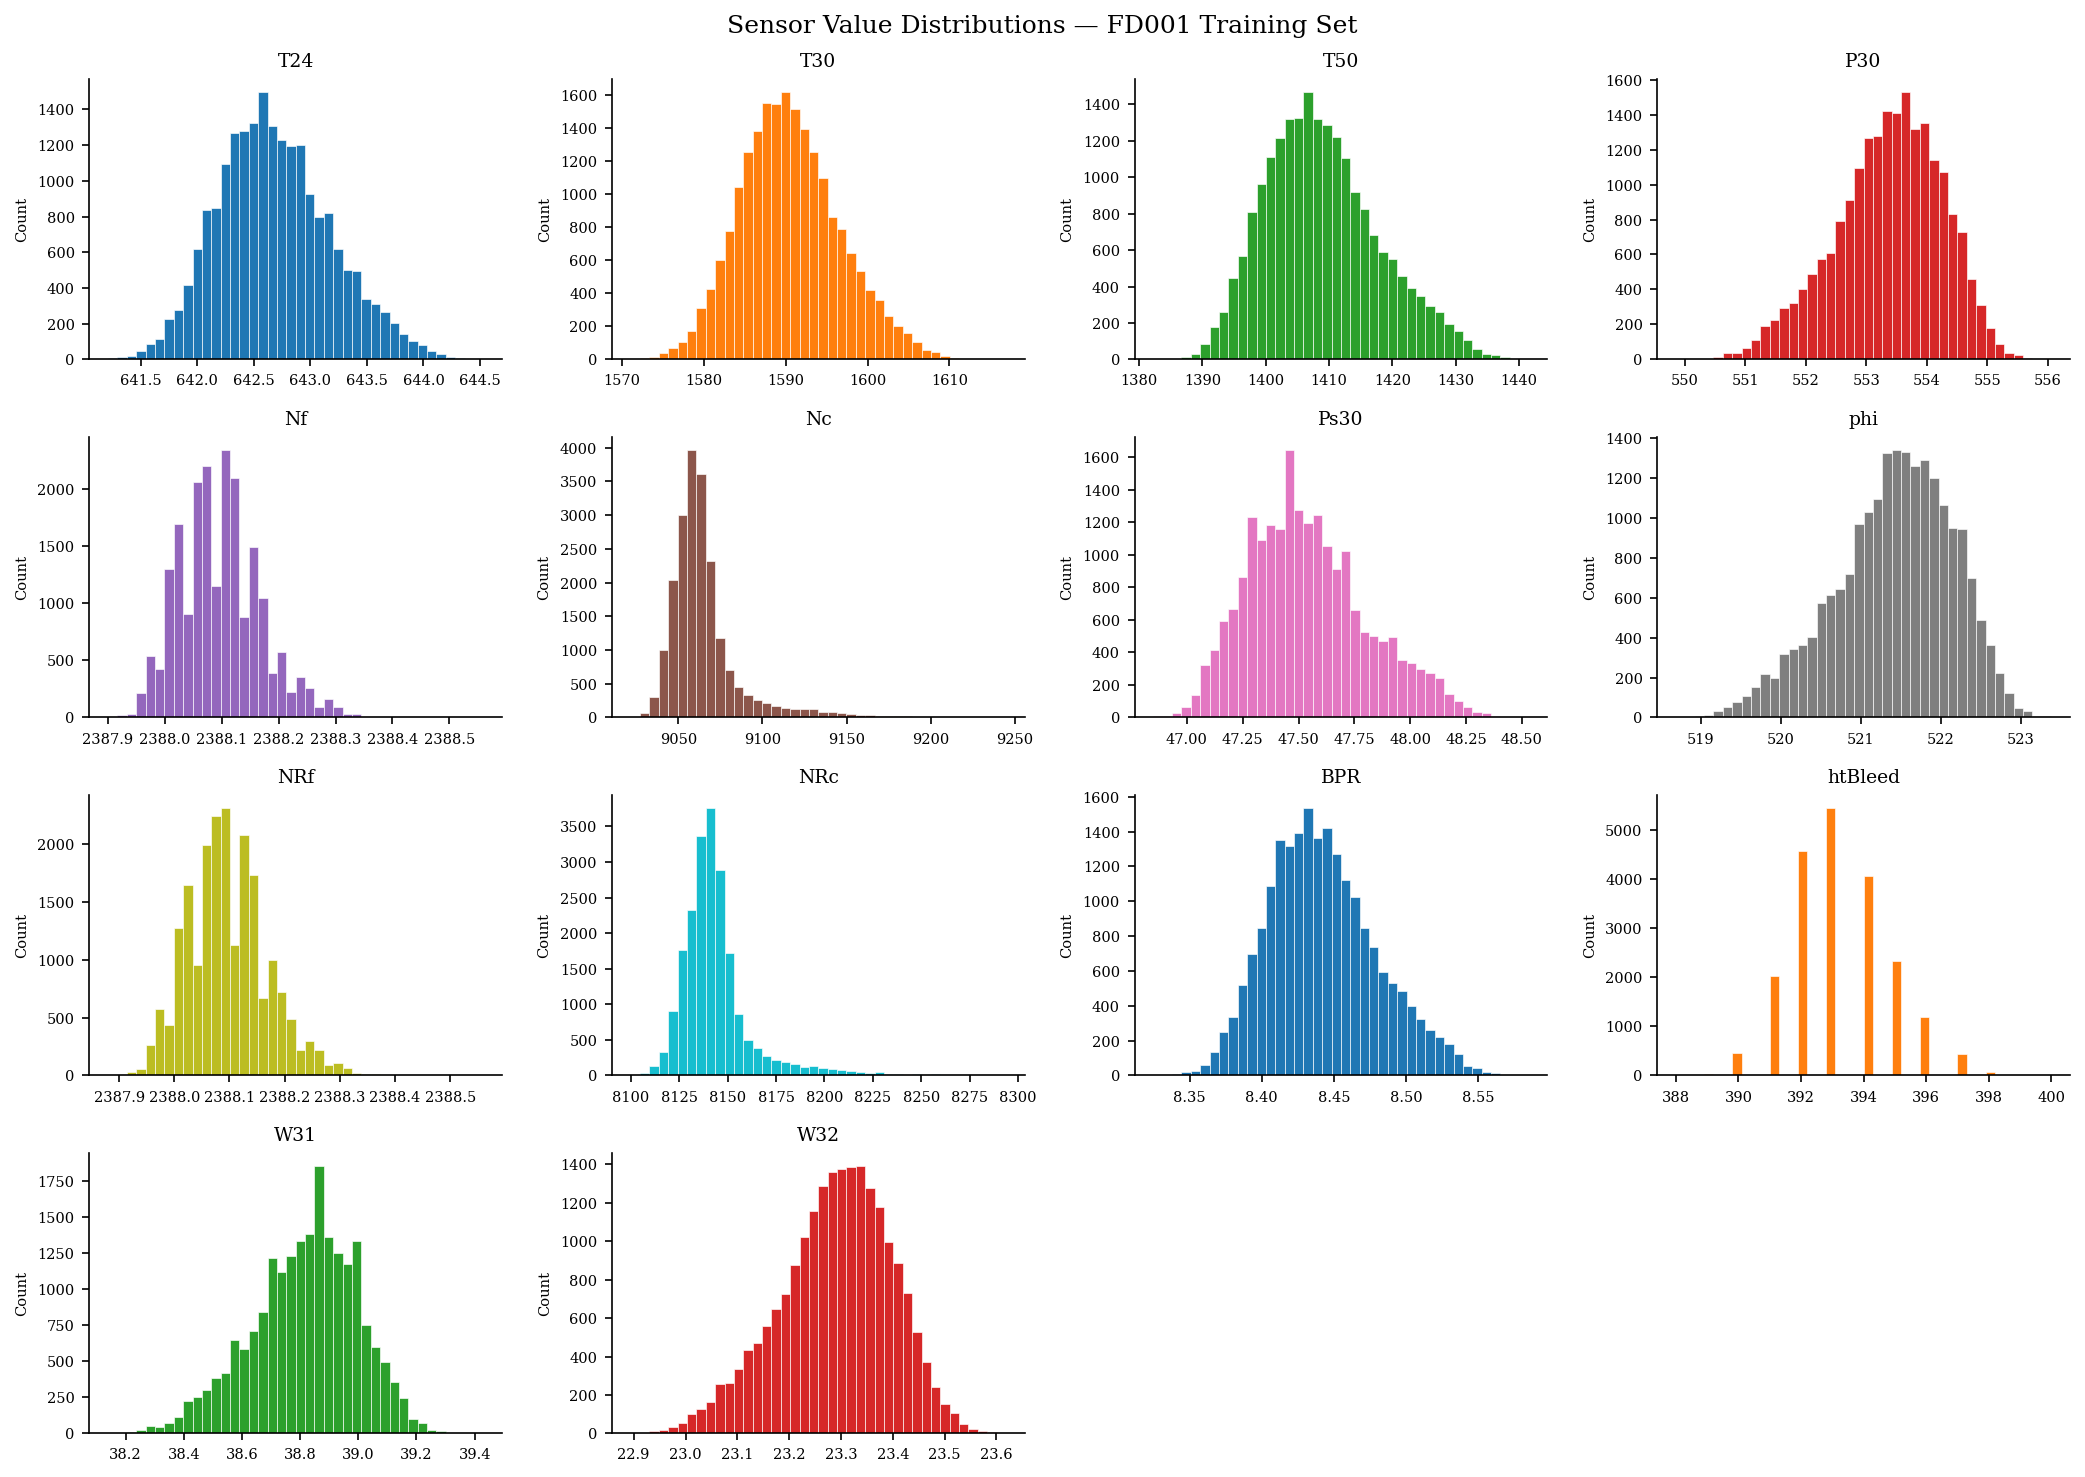

Saved → output/figures/IDA/sensor_distributions_FD001.png


In [19]:
# Side-by-side distributions of informative sensors (FD001 training set)
INFORMATIVE_SENSORS = ['T24', 'T30', 'T50', 'P30', 'Nf', 'Nc', 'Ps30', 'phi',
                        'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']

tr = data['FD001']['train']

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
fig.suptitle('Sensor Value Distributions — FD001 Training Set', fontsize=12)
axes = axes.flatten()

for i, s in enumerate(INFORMATIVE_SENSORS):
    ax = axes[i]
    ax.hist(tr[s].dropna(), bins=40, color=PALETTE[i % 10], edgecolor='white', linewidth=0.3)
    ax.set_title(s, fontsize=9)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(INFORMATIVE_SENSORS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_distributions_FD001.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/sensor_distributions_FD001.png')

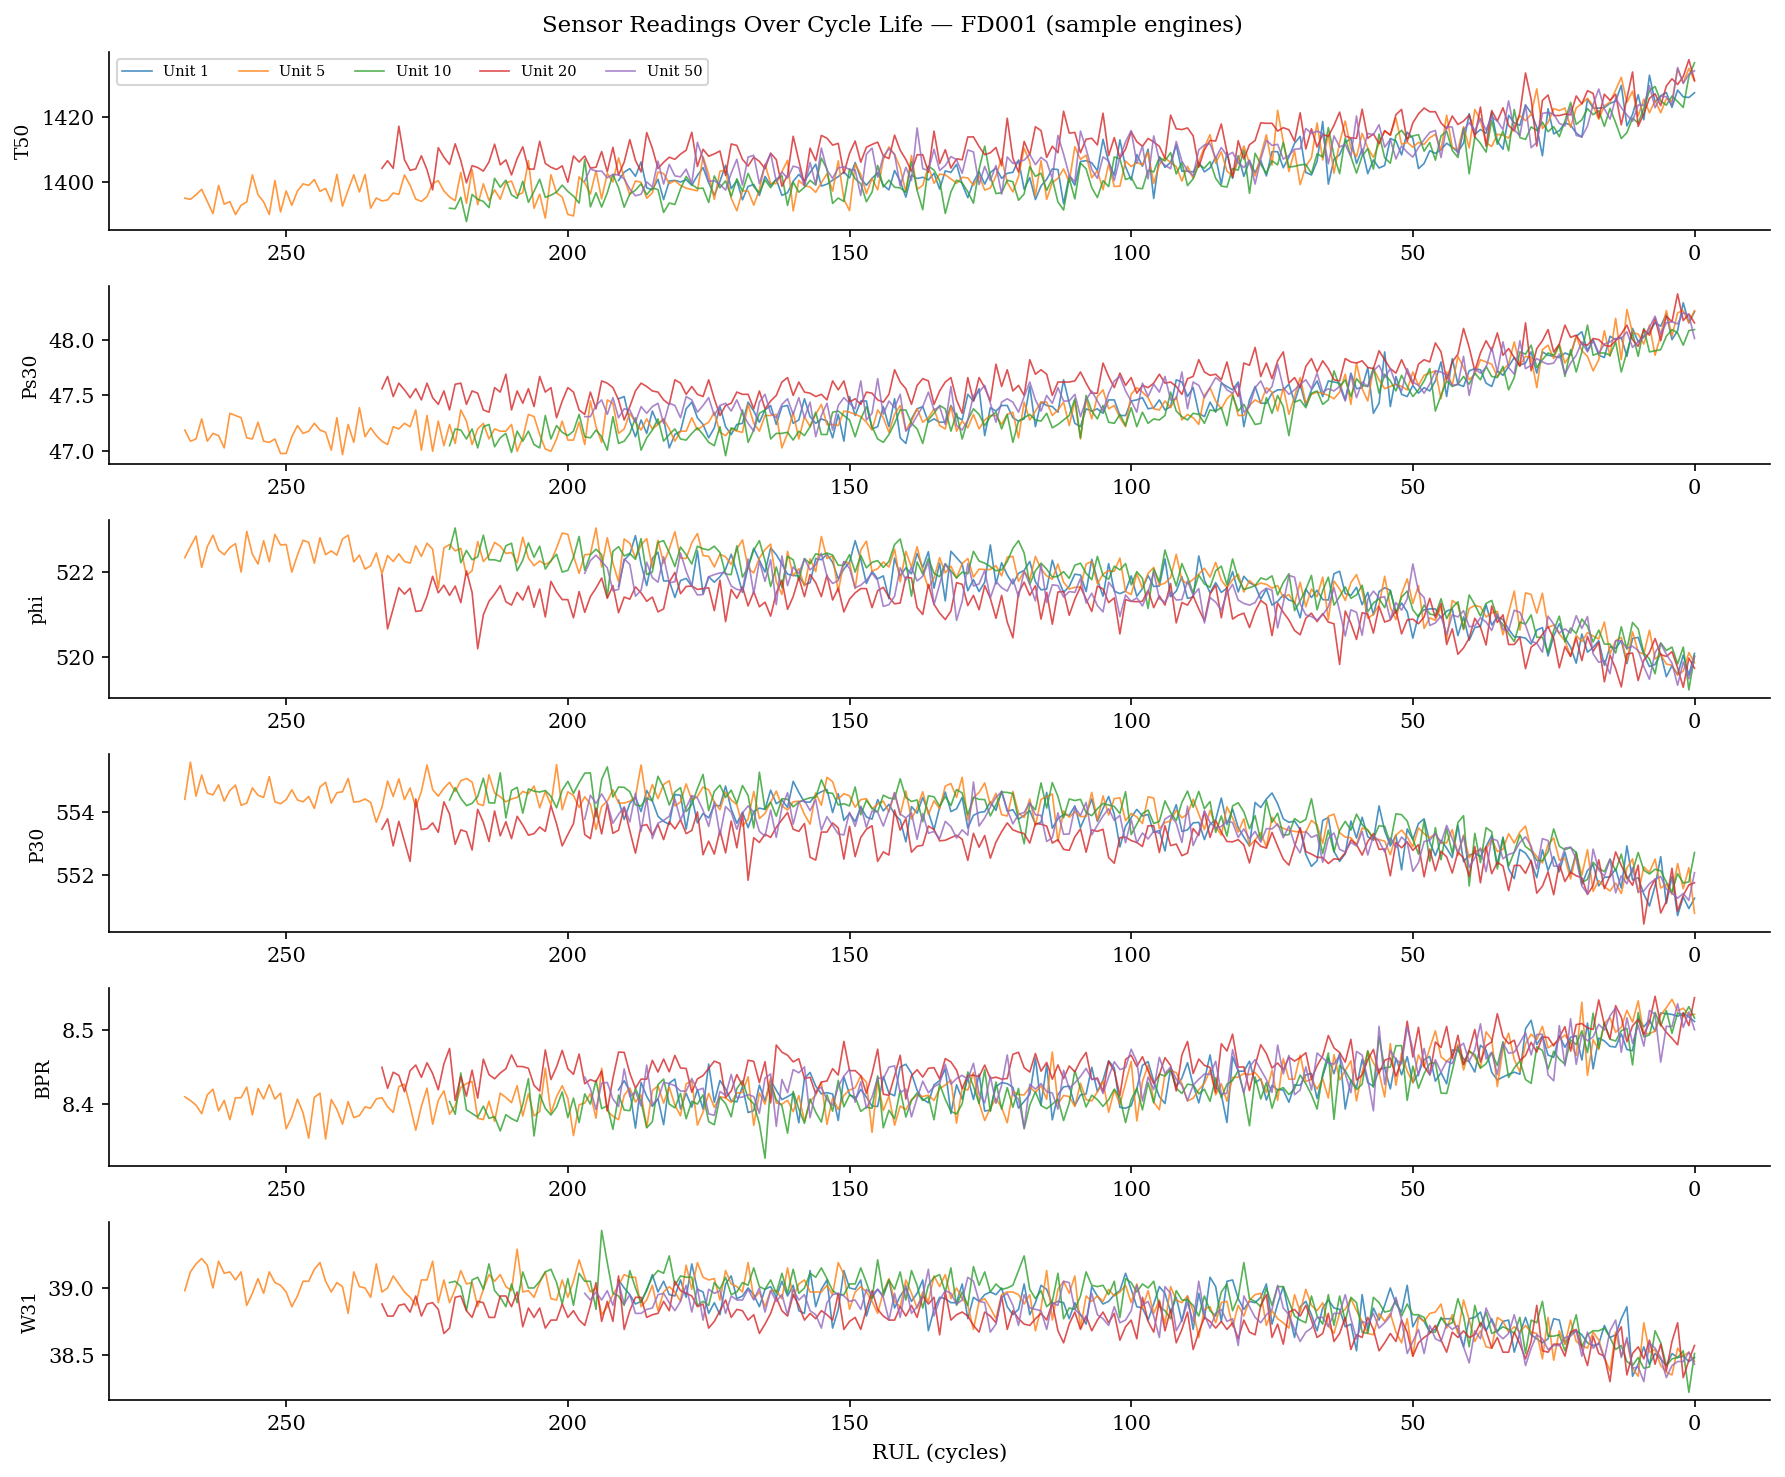

Saved → output/figures/IDA/sensor_timeseries_FD001.png


In [20]:
# Raw time-series for a sample of engines — visualise degradation in sensor readings
SAMPLE_UNITS = [1, 5, 10, 20, 50]
PLOT_SENSORS = ['T50', 'Ps30', 'phi', 'P30', 'BPR', 'W31']

tr = data['FD001']['train']
fig, axes = plt.subplots(len(PLOT_SENSORS), 1, figsize=(12, 10), sharex=False)
fig.suptitle('Sensor Readings Over Cycle Life — FD001 (sample engines)', fontsize=11)

for i, s in enumerate(PLOT_SENSORS):
    ax = axes[i]
    for j, uid in enumerate(SAMPLE_UNITS):
        unit_df = tr[tr['unit_id'] == uid]
        ax.plot(unit_df['RUL'], unit_df[s],
                linewidth=0.8, alpha=0.8, color=PALETTE[j], label=f'Unit {uid}')
    ax.invert_xaxis()  # RUL decreases to 0 at failure
    ax.set_ylabel(s, fontsize=9)
    ax.set_xlabel('RUL (cycles)' if i == len(PLOT_SENSORS) - 1 else '')
    if i == 0:
        ax.legend(fontsize=7, ncol=len(SAMPLE_UNITS))

plt.tight_layout()
fig.savefig(FIG_DIR / 'sensor_timeseries_FD001.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/sensor_timeseries_FD001.png')

---
## 10. RUL Label Structure

For **training** data, RUL is derived internally (`max_cycle - current_cycle`).  
For **test** data, true RUL labels are provided in separate files (`RUL_FD*.txt`), representing the remaining life at the last observed cycle.

In [21]:
rul_rows = []
for ds in DATASETS:
    rul = data[ds]['rul']
    train_rul = data[ds]['train'].groupby('unit_id')['RUL'].max()
    rul_rows.append({
        'Dataset': ds,
        'Test RUL — min': int(rul.min()),
        'Test RUL — median': int(rul.median()),
        'Test RUL — mean': f'{rul.mean():.1f}',
        'Test RUL — max': int(rul.max()),
        'Train max RUL (median)': int(train_rul.median()),
    })

rul_df = pd.DataFrame(rul_rows).set_index('Dataset')
display(rul_df)
rul_df.to_csv(TABLE_DIR / 'rul_label_stats.csv')
print('Saved → output/tables/IDA/rul_label_stats.csv')

,Test RUL — min,Test RUL — median,Test RUL — mean,Test RUL — max,Train max RUL (median)
Dataset,,,,,
FD001,7,86,75.5,145,198
FD002,6,80,81.2,194,198
FD003,6,77,75.3,145,219
FD004,6,88,86.6,195,233


Saved → output/tables/IDA/rul_label_stats.csv


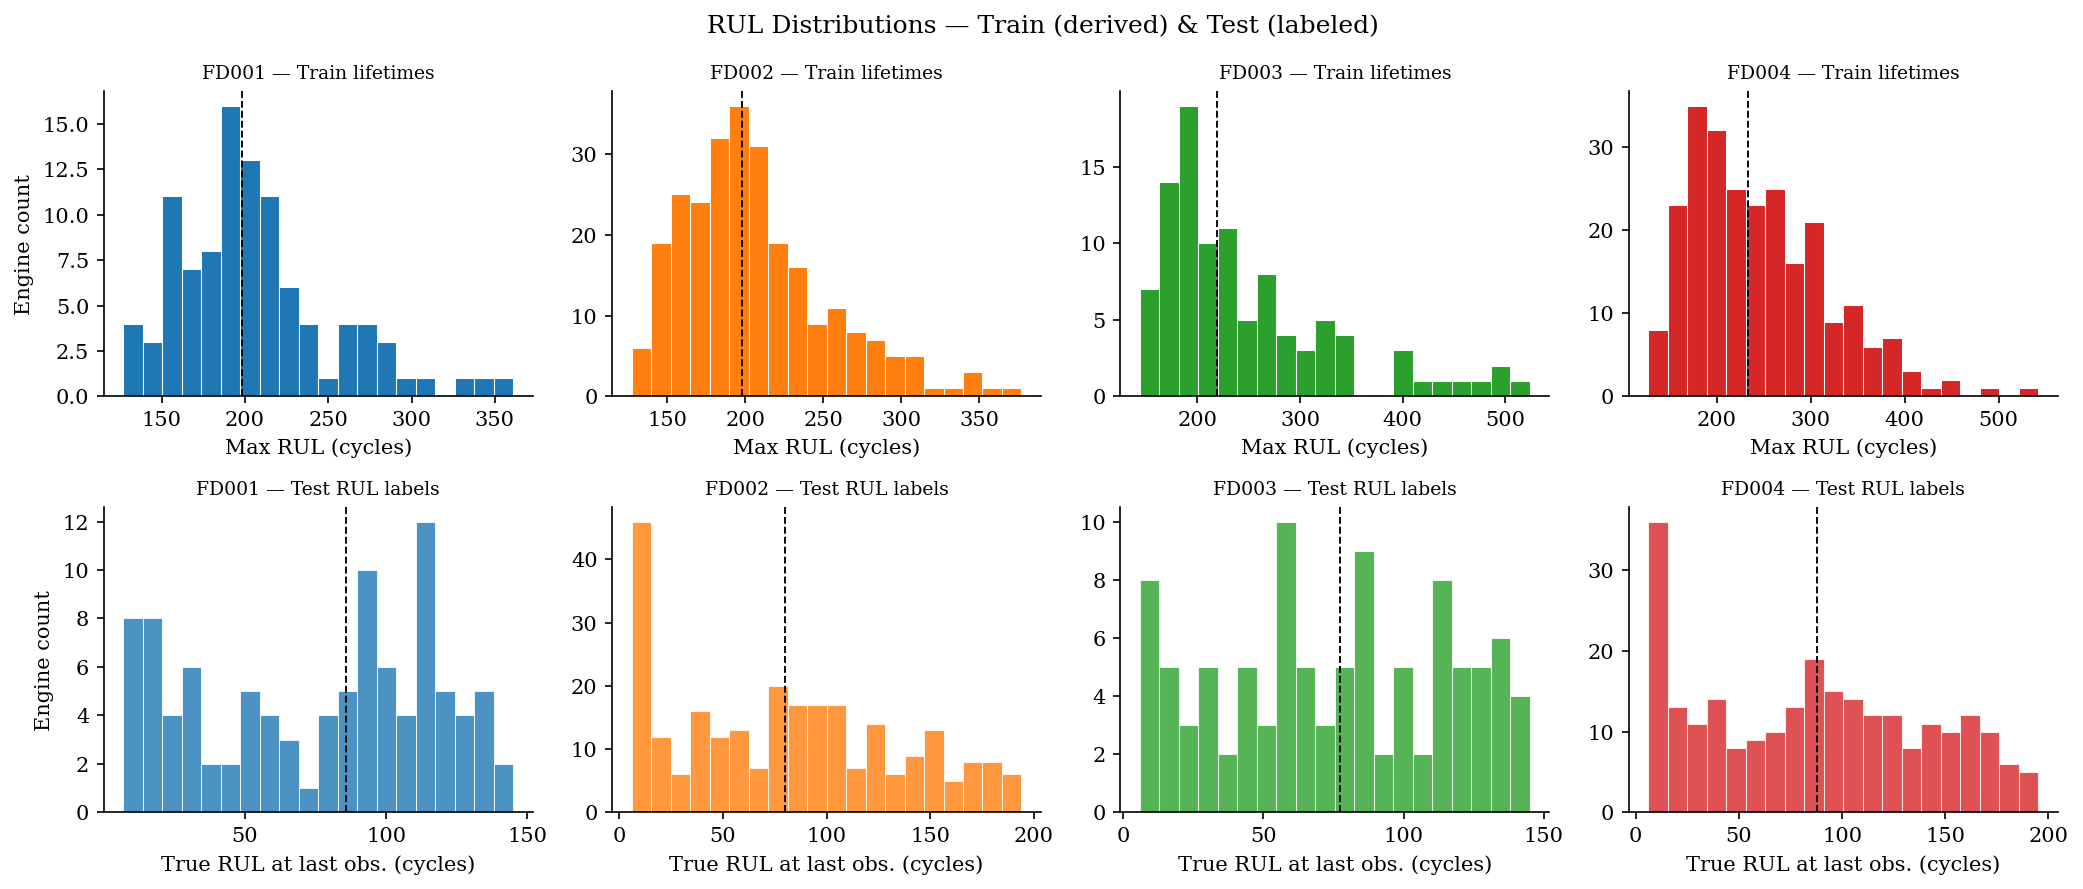

Saved → output/figures/IDA/rul_distributions.png


In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('RUL Distributions — Train (derived) & Test (labeled)', fontsize=12)

for col, ds in enumerate(DATASETS):
    # Training RUL per engine (max RUL = engine lifetime)
    ax = axes[0, col]
    train_max_rul = data[ds]['train'].groupby('unit_id')['RUL'].max()
    ax.hist(train_max_rul, bins=20, color=PALETTE[col], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{ds} — Train lifetimes', fontsize=9)
    ax.set_xlabel('Max RUL (cycles)')
    ax.set_ylabel('Engine count' if col == 0 else '')
    ax.axvline(train_max_rul.median(), color='k', linestyle='--', linewidth=0.9)

    # Test RUL labels
    ax = axes[1, col]
    rul = data[ds]['rul']
    ax.hist(rul, bins=20, color=PALETTE[col], edgecolor='white', linewidth=0.5, alpha=0.8)
    ax.set_title(f'{ds} — Test RUL labels', fontsize=9)
    ax.set_xlabel('True RUL at last obs. (cycles)')
    ax.set_ylabel('Engine count' if col == 0 else '')
    ax.axvline(rul.median(), color='k', linestyle='--', linewidth=0.9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'rul_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/rul_distributions.png')

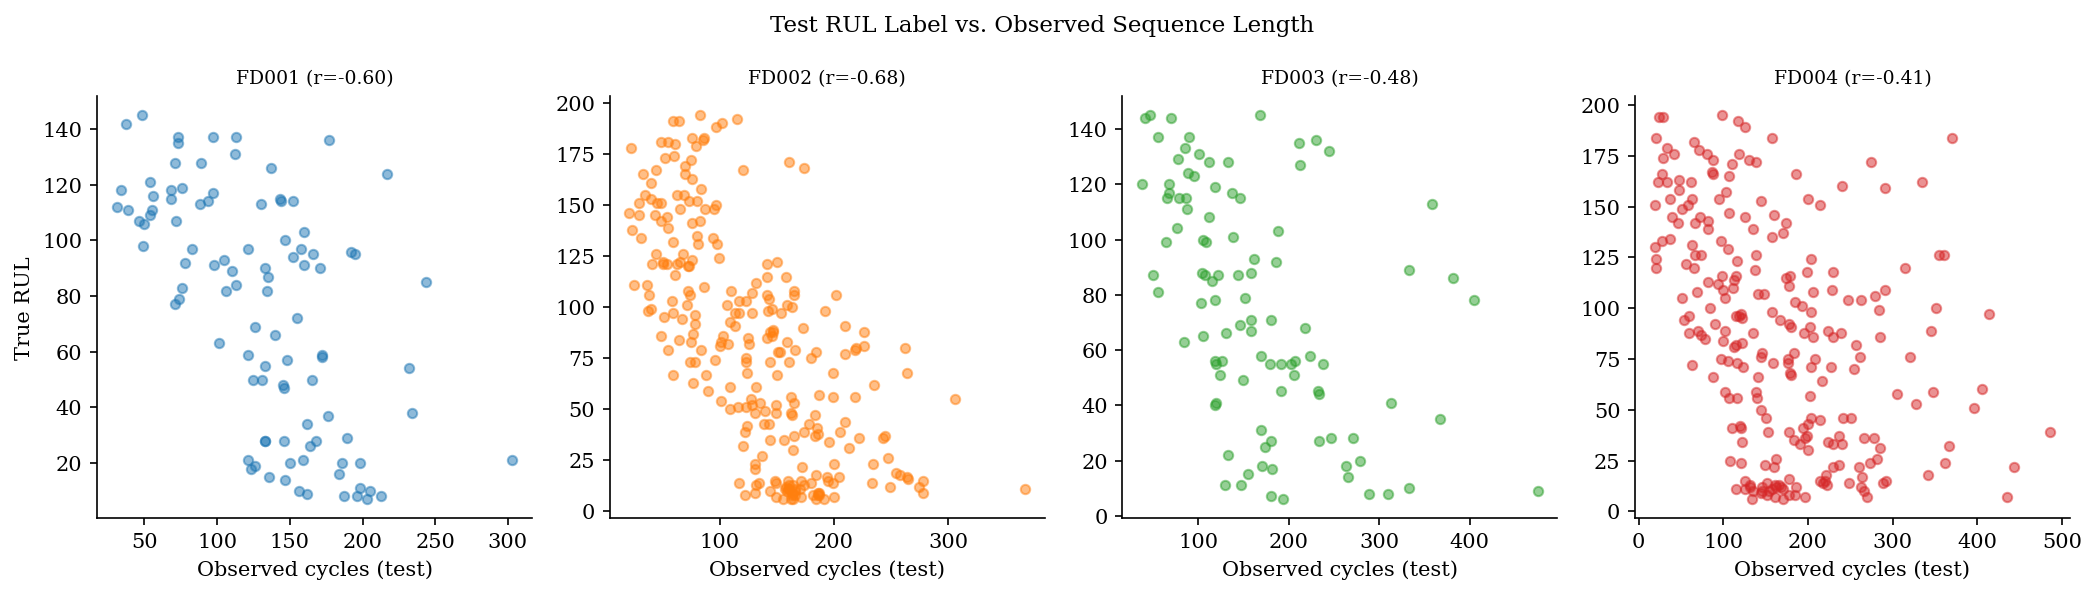

Saved → output/figures/IDA/test_rul_vs_obs_length.png


In [23]:
# Correlation between test RUL label and observed sequence length
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Test RUL Label vs. Observed Sequence Length', fontsize=11)

for i, ds in enumerate(DATASETS):
    ax = axes[i]
    te = data[ds]['test']
    obs_len = te.groupby('unit_id')['cycle'].max().values
    rul_vals = data[ds]['rul'].values
    corr = np.corrcoef(obs_len, rul_vals)[0, 1]
    ax.scatter(obs_len, rul_vals, alpha=0.5, s=20, color=PALETTE[i])
    ax.set_title(f'{ds} (r={corr:.2f})', fontsize=9)
    ax.set_xlabel('Observed cycles (test)')
    ax.set_ylabel('True RUL' if i == 0 else '')

plt.tight_layout()
fig.savefig(FIG_DIR / 'test_rul_vs_obs_length.png', bbox_inches='tight')
plt.show()
print('Saved → output/figures/IDA/test_rul_vs_obs_length.png')

---
## 11. Summary & Key Findings

In [24]:
print('=' * 65)
print('  IDA SUMMARY — NASA C-MAPSS')
print('=' * 65)

print("""
SCHEMA
  26 columns: unit_id | cycle | 3 settings | 21 sensors
  All columns numeric; no missing values in any split.
  No duplicate rows detected.

DATASETS
  FD001: 100 train engines, 100 test engines (1 op. condition)
  FD002: 260 train engines, 259 test engines (6 op. conditions)
  FD003: 100 train engines, 100 test engines (1 op. condition)
  FD004: 249 train engines, 248 test engines (6 op. conditions)

CYCLE STRUCTURE
  Train sequences = full engine lifetimes (failure observed).
  Test sequences = truncated (engine still running at last obs.).
  Lifetime range: ~130–360 cycles (FD001 train); varies by dataset.
  setting_3 is constant in all datasets → drop.

OPERATING CONDITIONS
  FD001/FD003: single op. condition → no cluster normalization needed.
  FD002/FD004: 6 distinct flight regimes (setting_1 + setting_2).
  Sensors must be normalized per operating condition for multi-regime datasets.

SENSORS — CONSTANT (zero variance, drop immediately)
  T2, P2, P15, epr, farB, Nf_dmd, PCNfR_dmd  (7 sensors, all datasets)

SENSORS — INFORMATIVE (14 remaining)
  T24, T30, T50, P30, Nf, Nc, Ps30, phi,
  NRf, NRc, BPR, htBleed, W31, W32
  → Further selection via EDA (Mann-Kendall, monotonicity, MI, VIF)

RUL LABELS
  Training RUL: derived from max_cycle − current_cycle (ramp-down from lifetime).
  Test RUL: provided externally; median ~100 cycles across datasets.
  Negative correlation between observed seq. length and test RUL
  (shorter sequences = less degradation seen = more RUL remaining).

NEXT STEP → EDA.ipynb
  Apply Mann-Kendall, monotonicity/trendability scores, MI, VIF
  to the 14 informative sensors to select the final sensor subset.
""")

  IDA SUMMARY — NASA C-MAPSS

SCHEMA
  26 columns: unit_id | cycle | 3 settings | 21 sensors
  All columns numeric; no missing values in any split.
  No duplicate rows detected.

DATASETS
  FD001: 100 train engines, 100 test engines (1 op. condition)
  FD002: 260 train engines, 259 test engines (6 op. conditions)
  FD003: 100 train engines, 100 test engines (1 op. condition)
  FD004: 249 train engines, 248 test engines (6 op. conditions)

CYCLE STRUCTURE
  Train sequences = full engine lifetimes (failure observed).
  Test sequences = truncated (engine still running at last obs.).
  Lifetime range: ~130–360 cycles (FD001 train); varies by dataset.
  setting_3 is constant in all datasets → drop.

OPERATING CONDITIONS
  FD001/FD003: single op. condition → no cluster normalization needed.
  FD002/FD004: 6 distinct flight regimes (setting_1 + setting_2).
  Sensors must be normalized per operating condition for multi-regime datasets.

SENSORS — CONSTANT (zero variance, drop immediately)
  T2

---
*End of IDA notebook. All tables and figures saved to `/output/tables/IDA/` and `/output/figures/IDA/`.*